In [677]:
import pymongo
from datetime import datetime, timedelta, timezone #import packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings("ignore")

In [651]:
myclient = pymongo.MongoClient("mongodb://localhost:27017/")
mydb = myclient["input"]
input = mydb["cleaned_data"]

cursor = input.find({}, {"_id": 0})

df = pd.DataFrame(list(cursor))

print(df.count())

timestamp           16813
light_raw           16813
temperature_c       16813
humidity_percent    16813
solar_raw           16813
battery_v           16813
dtype: int64


In [652]:
time_cutoff = {"timestamp" : {"$gt": datetime(2026,5, 20, 9, 49, 55, 65)}}
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

cutoff = pd.Timestamp(
    year=2026,
    month=5,
    day=20,
    hour=9,
    minute=49,
    second=55,
    microsecond=647000,
    tz="UTC"
)

df = df[
    (df["timestamp"] < cutoff) &
    (df["light_raw"] < 150) &
    (df["solar_raw"] < 150)
]

input.delete_many(time_cutoff)

DeleteResult({'n': 0, 'ok': 1.0}, acknowledged=True)

In [692]:
timestamp_cur = input.find({}, {"timestamp": 1, "_id": 0})

prev = first = next(timestamp_cur)

for i, x in enumerate(timestamp_cur):
    if i == 0:
        continue

    cur = x["timestamp"]
    
    diff = cur - prev["timestamp"]

    if abs(diff) > timedelta(seconds=24):
        print(cur, prev["timestamp"], diff.total_seconds())  #find timestmaps with a delay of more than 24 seconds plus overlapping timestamps

    prev = x

2026-05-17 16:08:45.889000 2026-05-17 16:23:52.424000 -906.535
2026-05-17 16:17:06.071000 2026-05-17 16:11:13.805000 352.266
2026-05-17 16:24:12.406000 2026-05-17 16:17:11.941000 420.465
2026-05-17 16:37:12.311000 2026-05-17 16:35:52.517000 79.794


In [654]:
def clean_and_interpolate(df):
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

    df = df.sort_values("timestamp").reset_index(drop=True)

    clean_rows = [df.iloc[0]]
    last_kept_time = df.loc[0, "timestamp"]

    for i in range(1, len(df)):
        cur_time = df.loc[i, "timestamp"]
        diff = (cur_time - last_kept_time).total_seconds()

        if diff < 17:
            continue

        clean_rows.append(df.iloc[i])
        last_kept_time = cur_time

    df = pd.DataFrame(clean_rows).reset_index(drop=True)

    df = df.set_index("timestamp")

    full_index = []
    times = df.index.to_list()

    for i in range(len(times) - 1):
        cur = times[i]
        nxt = times[i + 1]

        full_index.append(cur)

        diff = (nxt - cur).total_seconds()

        if diff > 24:
            missing_times = pd.date_range(
                start=cur + pd.Timedelta(seconds=20),
                end=nxt - pd.Timedelta(seconds=17),
                freq="20s"
            )

            full_index.extend(missing_times)

    full_index.append(times[-1])

    df = df.reindex(pd.DatetimeIndex(full_index).drop_duplicates().sort_values())

    numeric_cols = df.select_dtypes(include="number").columns
    df[numeric_cols] = df[numeric_cols].interpolate(method="time")

    df = df.reset_index().rename(columns={"index": "timestamp"})

    return df

df = clean_and_interpolate(df)

timestamp           16775
light_raw           16775
temperature_c       16775
humidity_percent    16775
solar_raw           16775
battery_v           16775
dtype: int64


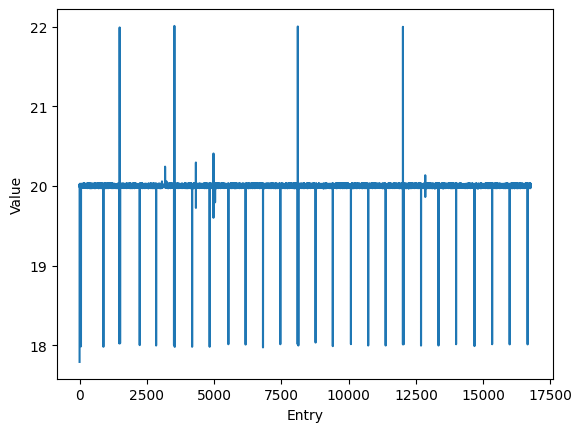

In [655]:
prev = df["timestamp"].iloc[0] #plot the delay to make sure timestamps are good

delay = []

for _, row in df.iterrows():
    diff = (row["timestamp"] - prev).total_seconds()
    delay.append(diff)

    prev = row["timestamp"]

print(df.count())

plt.plot(delay[1:len(delay)-15])

plt.xlabel("Entry")
plt.ylabel("Value")

plt.show()

In [656]:
numeric_cols = df.select_dtypes(include="number").columns

mask = pd.Series(True, index=df.index)

for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()

    z = (df[col] - mean) / std

    outliers = abs(z) > 3

    print(outliers.sum(), "outliers for:", col)

    mask &= abs(z) < 3

235 outliers for: light_raw
0 outliers for: temperature_c
0 outliers for: humidity_percent
297 outliers for: solar_raw
0 outliers for: battery_v


In [657]:
df = df[mask]

In [658]:
print(len(df))

16472


In [659]:
numeric_cols = df.select_dtypes(include="number").columns

mask = pd.Series(True, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    outlier_mask = (
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    )

    print(col, outlier_mask.sum())

    mask &= ~outlier_mask

light_raw 1057
temperature_c 0
humidity_percent 0
solar_raw 1182
battery_v 0


In [660]:
df = df[mask]


In [661]:
print(len(df))

15277


In [662]:
df = clean_and_interpolate(df)

(16775, 6)


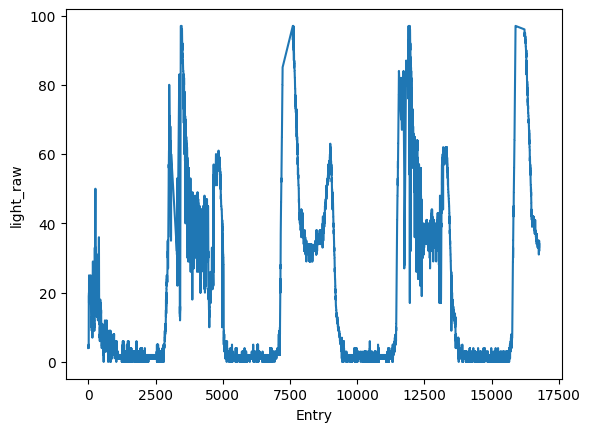

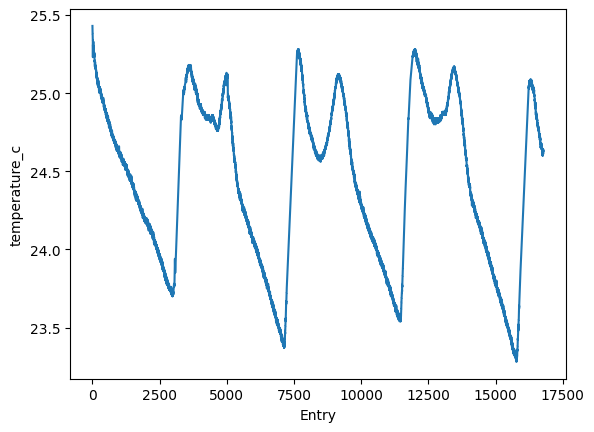

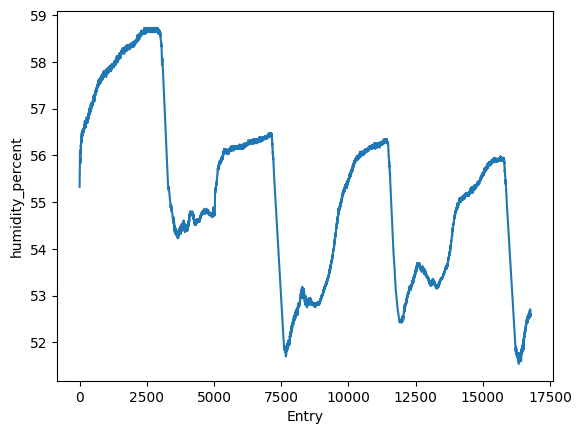

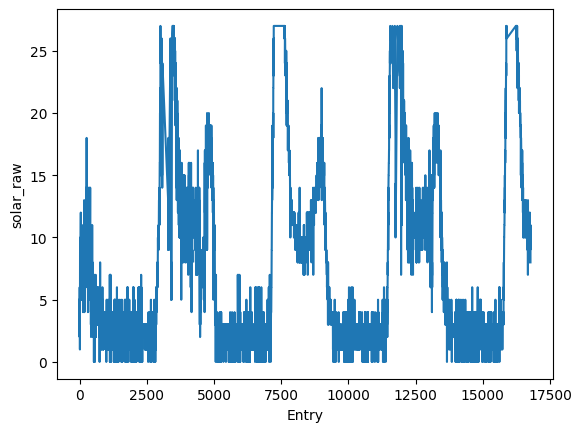

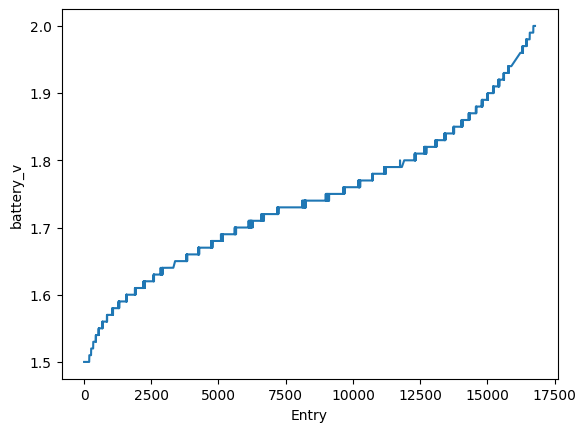

In [663]:
def show_plots(df1):
    print(df1.shape)
    numeric_cols = df1.select_dtypes(include="number").columns

    for col in numeric_cols:

        plt.plot(df1[col])

        plt.xlabel("Entry")
        plt.ylabel(str(col))

        plt.show()
show_plots(df)

In [664]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    median_filtered = (
        df[col]
        .rolling(9, center=True)
        .median()
    )

(16775, 6)


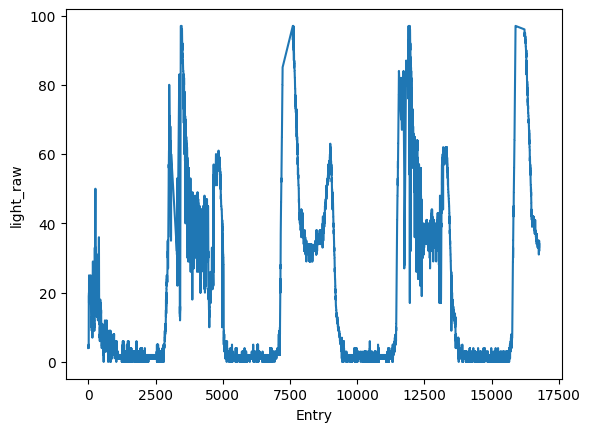

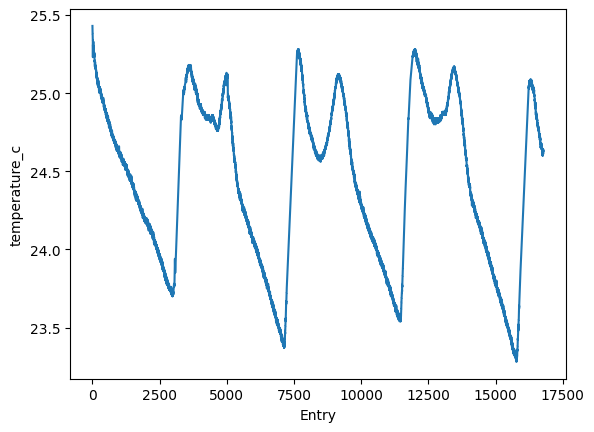

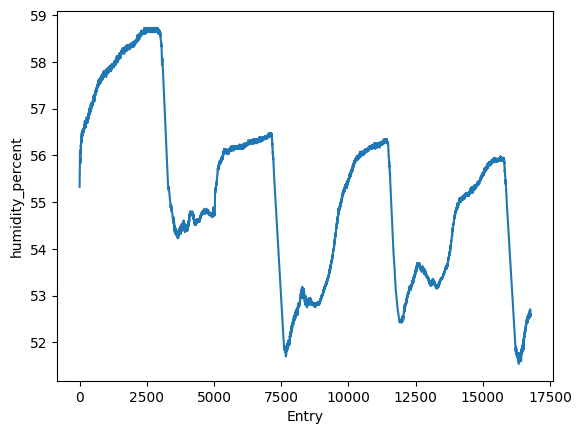

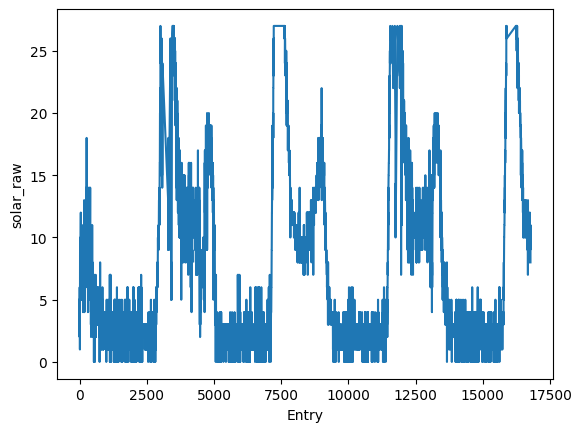

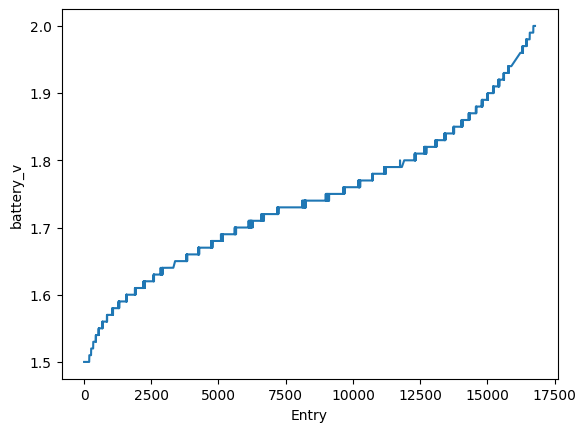

In [665]:
show_plots(df)

In [666]:
print(len(df.dropna()) - len(df))

0


In [674]:
corr = df.corr(numeric_only=True).round(4)

corr.to_excel(
    "correlation_matrix.xlsx",
    engine="openpyxl"
)

In [ ]:
SENSOR_COLS = [
    "temperature_c",
    "humidity_percent",
    "light_raw",
    "solar_raw",
    "battery_v",
]
TIMESTAMP_COL = "timestamp"
PALETTE = "magma"
DARK_BG = "#0f0f14"
ACCENT = "#e8c547"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": "#16161f",
    "axes.edgecolor": "#2a2a3a",
    "axes.labelcolor": "#c8c8d8",
    "xtick.color": "#888899",
    "ytick.color": "#888899",
    "text.color": "#c8c8d8",
    "grid.color": "#1e1e2e",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "monospace",
})


def load_and_prepare(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.set_index(TIMESTAMP_COL)
    df[SENSOR_COLS] = df[SENSOR_COLS].apply(pd.to_numeric, errors="coerce")
    print(f"[LOAD] {len(df)} valid samples | "
          f"{df.index.min()} → {df.index.max()}")
    return df

def print_best_features(feat_df: pd.DataFrame,
                        corr: pd.DataFrame,
                        threshold=0.90,
                        min_variance=1e-6):

    cols = corr.columns.tolist()

    remove = set()

    variances = feat_df.var()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):

            c1 = cols[i]
            c2 = cols[j]

            value = corr.iloc[i, j]

            if abs(value) >= threshold:

                v1 = variances[c1]
                v2 = variances[c2]

                if v1 >= v2:
                    remove.add(c2)
                    keep = c1
                    dropped = c2
                else:
                    remove.add(c1)
                    keep = c2
                    dropped = c1

                print(
                    f"[REMOVE] {dropped:<40} "
                    f"| keep={keep:<40} "
                    f"| corr={value:.3f}"
                )

    best_features = [
        c for c in cols
        if c not in remove and variances[c] > min_variance
    ]

    print("\n" + "=" * 60)
    print("BEST FEATURES")
    print("=" * 60)

    for f in best_features:
        print(f)

    print(f"\n[FINAL] {len(best_features)} features kept")

    return best_features

def rolling_features(df: pd.DataFrame, windows_min=[15, 60, 360]) -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        s = df[col]
        for w in windows_min:
            r = s.rolling(f"{w}min", min_periods=2)
            feats[f"{col}__roll_mean_{w}m"]  = r.mean()
            feats[f"{col}__roll_std_{w}m"]   = r.std()
            feats[f"{col}__roll_range_{w}m"] = r.max() - r.min()
    return pd.DataFrame(feats, index=df.index)


def lag_features(df: pd.DataFrame, lags=[1, 5, 15]) -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        for lag in lags:
            feats[f"{col}__lag_{lag}"] = df[col].shift(lag)
    return pd.DataFrame(feats, index=df.index)


def delta_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        feats[f"{col}__delta1"] = df[col].diff(1)
        feats[f"{col}__delta2"] = df[col].diff(1).diff(1)
    return pd.DataFrame(feats, index=df.index)


def diurnal_features(df: pd.DataFrame) -> pd.DataFrame:
    idx = df.index
    hour = idx.hour + idx.minute / 60.0
    feats = {
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "day_of_week": idx.dayofweek.astype(float),
        "is_daytime": ((hour >= 6) & (hour <= 20)).astype(float),
        "hour_bin": pd.cut(hour, bins=[0, 6, 12, 18, 24],
                           labels=[0, 1, 2, 3], right=False).astype(float),
    }
    return pd.DataFrame(feats, index=df.index)


def statistical_features(df: pd.DataFrame, window="1H") -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        s = df[col]
        r = s.rolling(window, min_periods=4)
        feats[f"{col}__skew_1h"]  = r.skew()
        feats[f"{col}__kurt_1h"]  = r.kurt()
        mean = r.mean()
        std  = r.std()
        feats[f"{col}__cv_1h"] = (std / mean.replace(0, np.nan)).abs()
    return pd.DataFrame(feats, index=df.index)


def cross_sensor_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = {}
    # Heat index proxy
    T = df["temperature_c"]
    H = df["humidity_percent"]
    feats["heat_index_proxy"] = T + 0.33 * (H / 100 * 6.105 *
        np.exp(17.27 * T / (237.7 + T))) - 4.0

    light = df["light_raw"].replace(0, np.nan)
    feats["solar_efficiency"] = df["solar_raw"] / light

    dt_h = df.index.to_series().diff().dt.total_seconds().fillna(0) / 3600
    feats["battery_drain_rate"] = -df["battery_v"].diff() / dt_h.replace(0, np.nan)

    return pd.DataFrame(feats, index=df.index)


def assemble_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    parts = [
        df[SENSOR_COLS],
        rolling_features(df),
        lag_features(df),
        delta_features(df),
        diurnal_features(df),
        statistical_features(df),
        cross_sensor_features(df),
    ]
    out = pd.concat(parts, axis=1)
    out = out.dropna()
    print(f"[FEATURES] Matrix shape: {out.shape[0]} rows × {out.shape[1]} columns")
    return out


def compute_correlation_matrices(df: pd.DataFrame):
    pearson  = df.corr(method="pearson")
    spearman = df.corr(method="spearman")
    kendall  = df.corr(method="kendall")
    return pearson, spearman, kendall


def compute_pvalue_matrix(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.columns
    n = len(cols)
    pvals = np.ones((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            s1 = df.iloc[:, i].dropna()
            s2 = df.iloc[:, j].dropna()
            common = s1.index.intersection(s2.index)
            if len(common) > 2:
                _, p = stats.pearsonr(s1[common], s2[common])
                pvals[i, j] = pvals[j, i] = p
    return pd.DataFrame(pvals, index=cols, columns=cols)

def plot_raw_timeseries(df: pd.DataFrame):
    fig, axes = plt.subplots(len(SENSOR_COLS), 1,
                              figsize=(16, 3 * len(SENSOR_COLS)),
                              sharex=True)
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(SENSOR_COLS)))
    for ax, col, c in zip(axes, SENSOR_COLS, colors):
        ax.plot(df.index, df[col], color=c, linewidth=0.8, alpha=0.9)
        ax.fill_between(df.index, df[col], alpha=0.12, color=c)
        ax.set_ylabel(col.replace("_", " "), fontsize=9)
        ax.grid(True)
    axes[-1].set_xlabel("Timestamp")
    fig.suptitle("RAW SENSOR TIME SERIES — 3-DAY WINDOW",
                 fontsize=13, fontweight="bold", color=ACCENT, y=1.01)
    fig.tight_layout()
    plt.savefig("01_raw_timeseries.png", dpi=150, bbox_inches="tight",
                facecolor=DARK_BG)
    plt.show()
    print("[PLOT] 01_raw_timeseries.png")


def plot_correlation_heatmap(corr: pd.DataFrame, pval: pd.DataFrame,
                              method: str, sig_level=0.05):
    """Publication-grade annotated correlation heatmap with significance mask."""
    # Mask insignificant cells
    sig_mask = pval > sig_level
    # Upper triangle mask
    tri_mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(14, 12))

    # Background heatmap
    sns.heatmap(
        corr, mask=tri_mask, ax=ax,
        cmap=PALETTE, center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.4, linecolor="#0f0f14",
        annot=True, fmt=".2f", annot_kws={"size": 7, "color": "white"},
        cbar_kws={"shrink": 0.75, "label": f"{method} r"},
    )

    # Hatch insignificant cells
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            if not tri_mask[i, j] and sig_mask.iloc[i, j]:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=True, color="#0f0f14", alpha=0.55,
                    hatch="///", linewidth=0
                ))

    ax.set_title(
        f"{method.upper()} CORRELATION MATRIX\n"
        f"(hatched = p > {sig_level}, n={corr.shape[0]} features)",
        fontsize=12, fontweight="bold", color=ACCENT, pad=14
    )
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
    fig.tight_layout()
    fname = f"02_corr_heatmap_{method.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print(f"[PLOT] {fname}")


def plot_sensor_only_heatmap(df_raw: pd.DataFrame):
    corr = df_raw[SENSOR_COLS].corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, ax=ax,
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        square=True, annot=True, fmt=".3f",
        linewidths=1, linecolor=DARK_BG,
        annot_kws={"size": 11, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title("SENSOR PAIR CORRELATIONS (Pearson)",
                 fontsize=11, fontweight="bold", color=ACCENT)
    fig.tight_layout()
    plt.savefig("03_sensor_corr_heatmap.png", dpi=150,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("[PLOT] 03_sensor_corr_heatmap.png")


def plot_rolling_correlation(df: pd.DataFrame, window="2H"):
    pairs = [
        ("temperature_c", "humidity_percent"),
        ("light_raw", "solar_raw"),
        ("temperature_c", "solar_raw"),
        ("battery_v", "solar_raw"),
    ]
    fig, axes = plt.subplots(len(pairs), 1, figsize=(16, 3 * len(pairs)),
                              sharex=True)
    colors = plt.cm.cool(np.linspace(0.2, 0.9, len(pairs)))
    for ax, (c1, c2), color in zip(axes, pairs, colors):
        roll_corr = df[c1].rolling(window).corr(df[c2])
        ax.plot(df.index, roll_corr, color=color, linewidth=1.0)
        ax.axhline(0, color="#555566", linewidth=0.8, linestyle="--")
        ax.axhline(0.7,  color="#55cc77", linewidth=0.6, linestyle=":")
        ax.axhline(-0.7, color="#cc5555", linewidth=0.6, linestyle=":")
        ax.set_ylim(-1.1, 1.1)
        ax.set_ylabel(f"r({c1[:4]}, {c2[:4]})", fontsize=8)
        ax.grid(True)
    axes[-1].set_xlabel("Timestamp")
    fig.suptitle(f"ROLLING PEARSON CORRELATION (window={window})",
                 fontsize=12, fontweight="bold", color=ACCENT)
    fig.tight_layout()
    plt.savefig("04_rolling_correlation.png", dpi=150,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("[PLOT] 04_rolling_correlation.png")


def plot_feature_importance_by_variance(feat_df: pd.DataFrame, top_n=30):
    var = feat_df.var().sort_values(ascending=False)
    var_norm = (var / var.max()).head(top_n)

    fig, ax = plt.subplots(figsize=(10, top_n * 0.35 + 1))
    colors = plt.cm.plasma(np.linspace(0.15, 0.85, top_n))
    bars = ax.barh(var_norm.index[::-1], var_norm.values[::-1],
                   color=colors, edgecolor="#0f0f14", height=0.75)
    ax.set_xlabel("Normalized Variance")
    ax.set_title(f"TOP {top_n} FEATURES BY VARIANCE",
                 fontsize=11, fontweight="bold", color=ACCENT)
    ax.grid(axis="x")
    fig.tight_layout()
    plt.savefig("05_feature_variance.png", dpi=150,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("[PLOT] 05_feature_variance.png")


def plot_diurnal_patterns(df: pd.DataFrame):
    df_h = df[SENSOR_COLS].copy()
    df_h["hour"] = df.index.hour

    fig, axes = plt.subplots(1, len(SENSOR_COLS), figsize=(20, 5))
    colors = plt.cm.magma(np.linspace(0.25, 0.85, len(SENSOR_COLS)))
    for ax, col, c in zip(axes, SENSOR_COLS, colors):
        groups = [df_h[df_h["hour"] == h][col].dropna().values
                  for h in range(24)]
        bp = ax.boxplot(groups, positions=range(24), widths=0.6,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color=ACCENT, linewidth=1.5))
        for patch in bp["boxes"]:
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(col.replace("_", " "), fontsize=8, color=ACCENT)
        ax.set_xlabel("Hour of Day", fontsize=7)
        ax.set_xticks(range(0, 24, 3))
        ax.grid(True)
    fig.suptitle("DIURNAL PATTERNS — HOURLY DISTRIBUTIONS",
                 fontsize=12, fontweight="bold", color=ACCENT)
    fig.tight_layout()
    plt.savefig("06_diurnal_boxplots.png", dpi=150,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("[PLOT] 06_diurnal_boxplots.png")


def plot_clustermap(feat_df: pd.DataFrame, top_n=40):
    var = feat_df.var().sort_values(ascending=False)
    top_feats = var.head(top_n).index.tolist()
    corr = feat_df[top_feats].corr()

    g = sns.clustermap(
        corr, cmap=PALETTE, center=0, vmin=-1, vmax=1,
        figsize=(16, 16), linewidths=0.3,
        annot=False, method="ward",
        dendrogram_ratio=0.12,
        cbar_pos=(0.02, 0.8, 0.03, 0.18),
    )
    g.fig.suptitle(
        f"HIERARCHICAL CLUSTER MAP — TOP {top_n} FEATURES",
        fontsize=12, fontweight="bold", color=ACCENT, y=1.01
    )
    g.fig.set_facecolor(DARK_BG)
    plt.savefig("07_clustermap.png", dpi=150,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("[PLOT] 07_clustermap.png")


def run_pipeline(df_raw: pd.DataFrame):
    print("=" * 60)
    print("  IoT SENSOR — FEATURE EXTRACTION & CORRELATION PIPELINE")
    print("=" * 60)

    # Prepare
    df = load_and_prepare(df_raw)

    # Feature matrix
    feat_df = assemble_feature_matrix(df)

    # Correlation matrices
    pearson, spearman, _ = compute_correlation_matrices(feat_df)
    best_features = print_best_features(feat_df, pearson)
    pval = compute_pvalue_matrix(feat_df)

    # ── PLOTS ──
    plot_raw_timeseries(df)
    plot_correlation_heatmap(pearson,  pval, method="Pearson")
    plot_correlation_heatmap(spearman, pval, method="Spearman")
    plot_sensor_only_heatmap(df)
    plot_rolling_correlation(df)
    plot_feature_importance_by_variance(feat_df, top_n=30)
    plot_diurnal_patterns(df)
    plot_clustermap(feat_df, top_n=40)

    print("\n[DONE] All 7 plots saved.")
    return feat_df, pearson, spearman


  IoT SENSOR — FEATURE EXTRACTION & CORRELATION PIPELINE
[LOAD] 16775 valid samples | 2026-05-16 12:38:16.398000+00:00 → 2026-05-20 09:49:31.666000+00:00
[FEATURES] Matrix shape: 16320 rows × 98 columns
[REMOVE] temperature_c                            | keep=temperature_c__roll_mean_15m             | corr=0.998
[REMOVE] temperature_c__roll_mean_60m             | keep=temperature_c                            | corr=0.971
[REMOVE] temperature_c                            | keep=temperature_c__lag_1                     | corr=1.000
[REMOVE] temperature_c                            | keep=temperature_c__lag_5                     | corr=1.000
[REMOVE] temperature_c                            | keep=temperature_c__lag_15                    | corr=0.999
[REMOVE] temperature_c                            | keep=heat_index_proxy                         | corr=0.969
[REMOVE] humidity_percent__roll_mean_15m          | keep=humidity_percent                         | corr=0.999
[REMOVE] humidity_pe

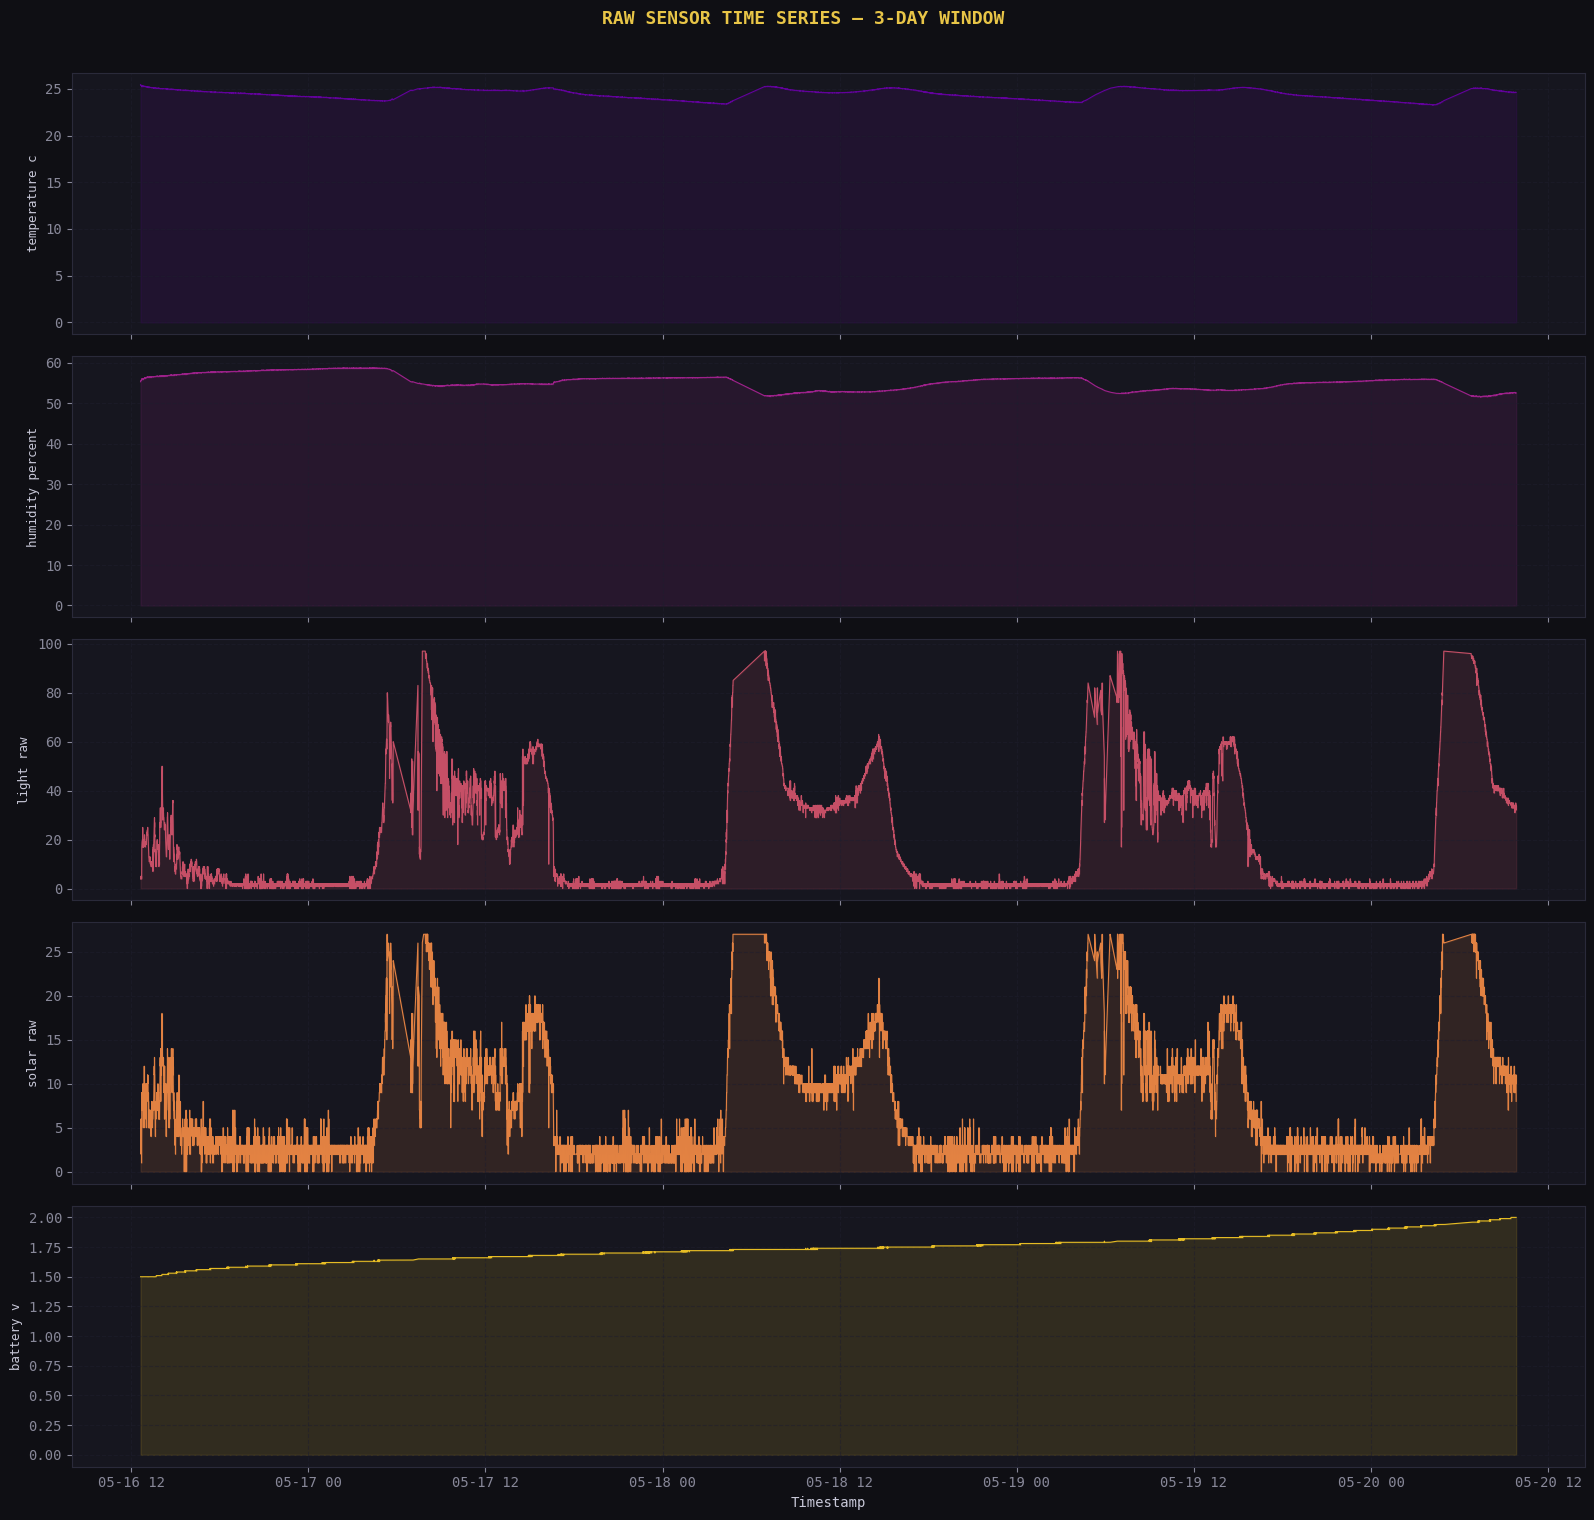

[PLOT] 01_raw_timeseries.png


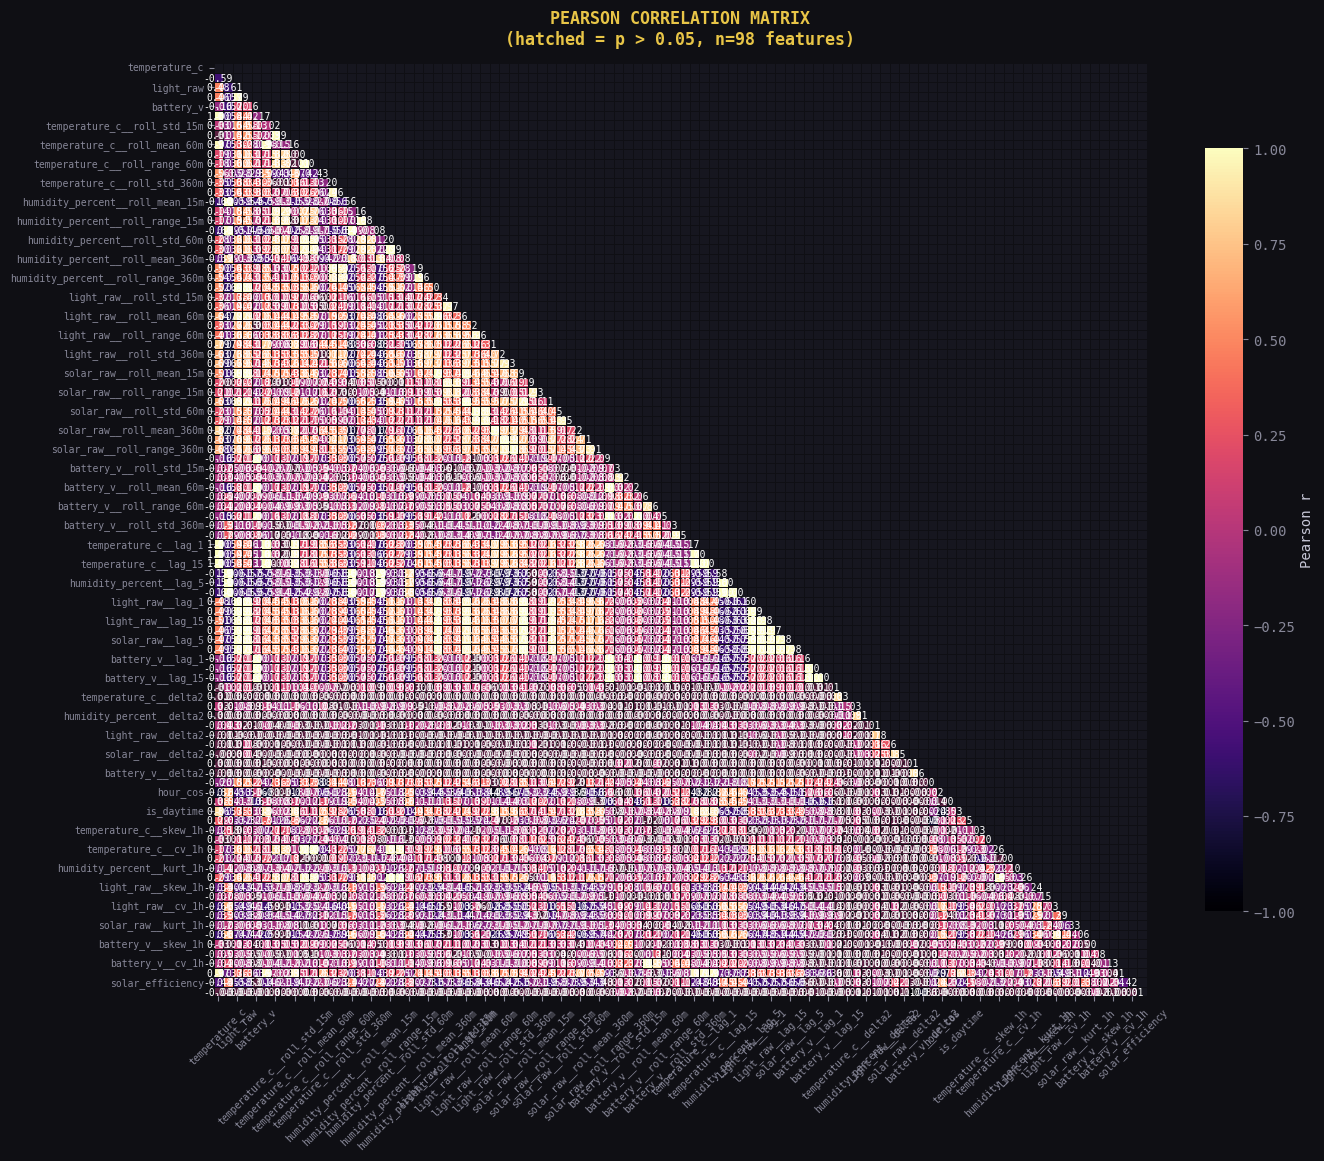

[PLOT] 02_corr_heatmap_pearson.png


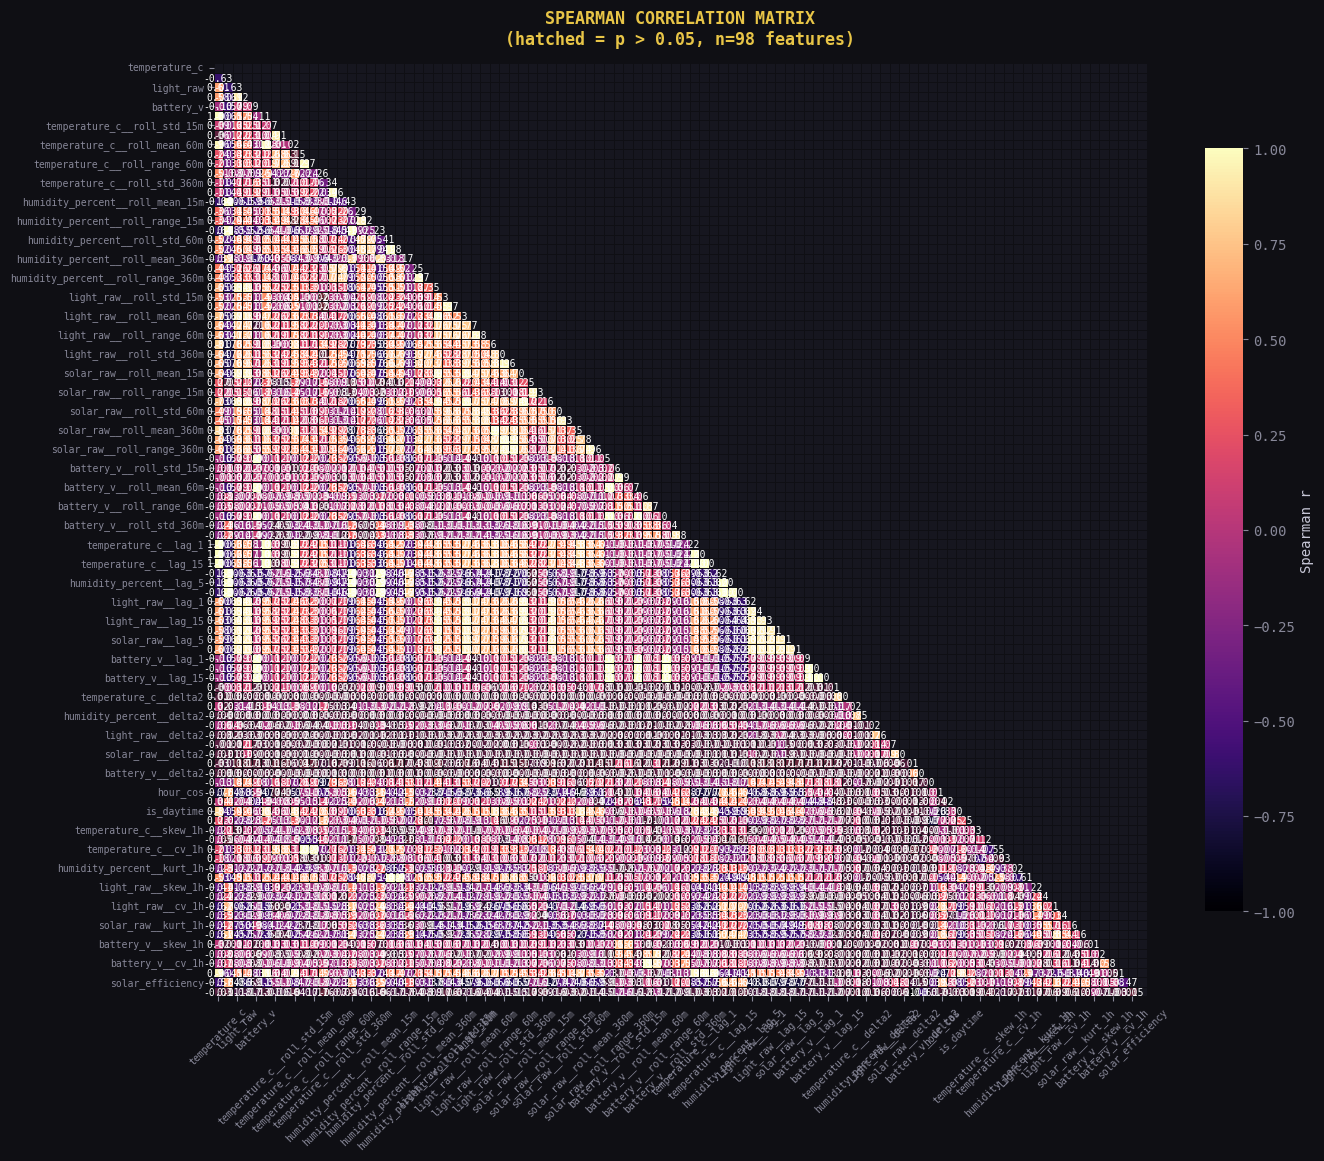

[PLOT] 02_corr_heatmap_spearman.png


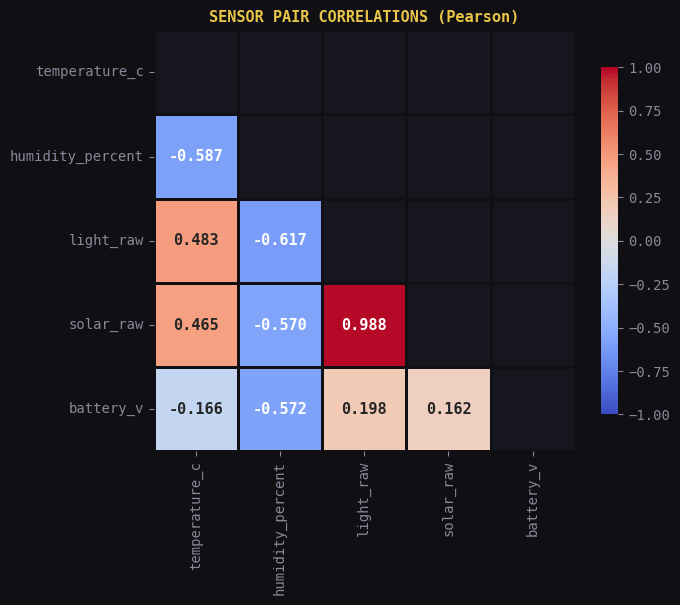

[PLOT] 03_sensor_corr_heatmap.png


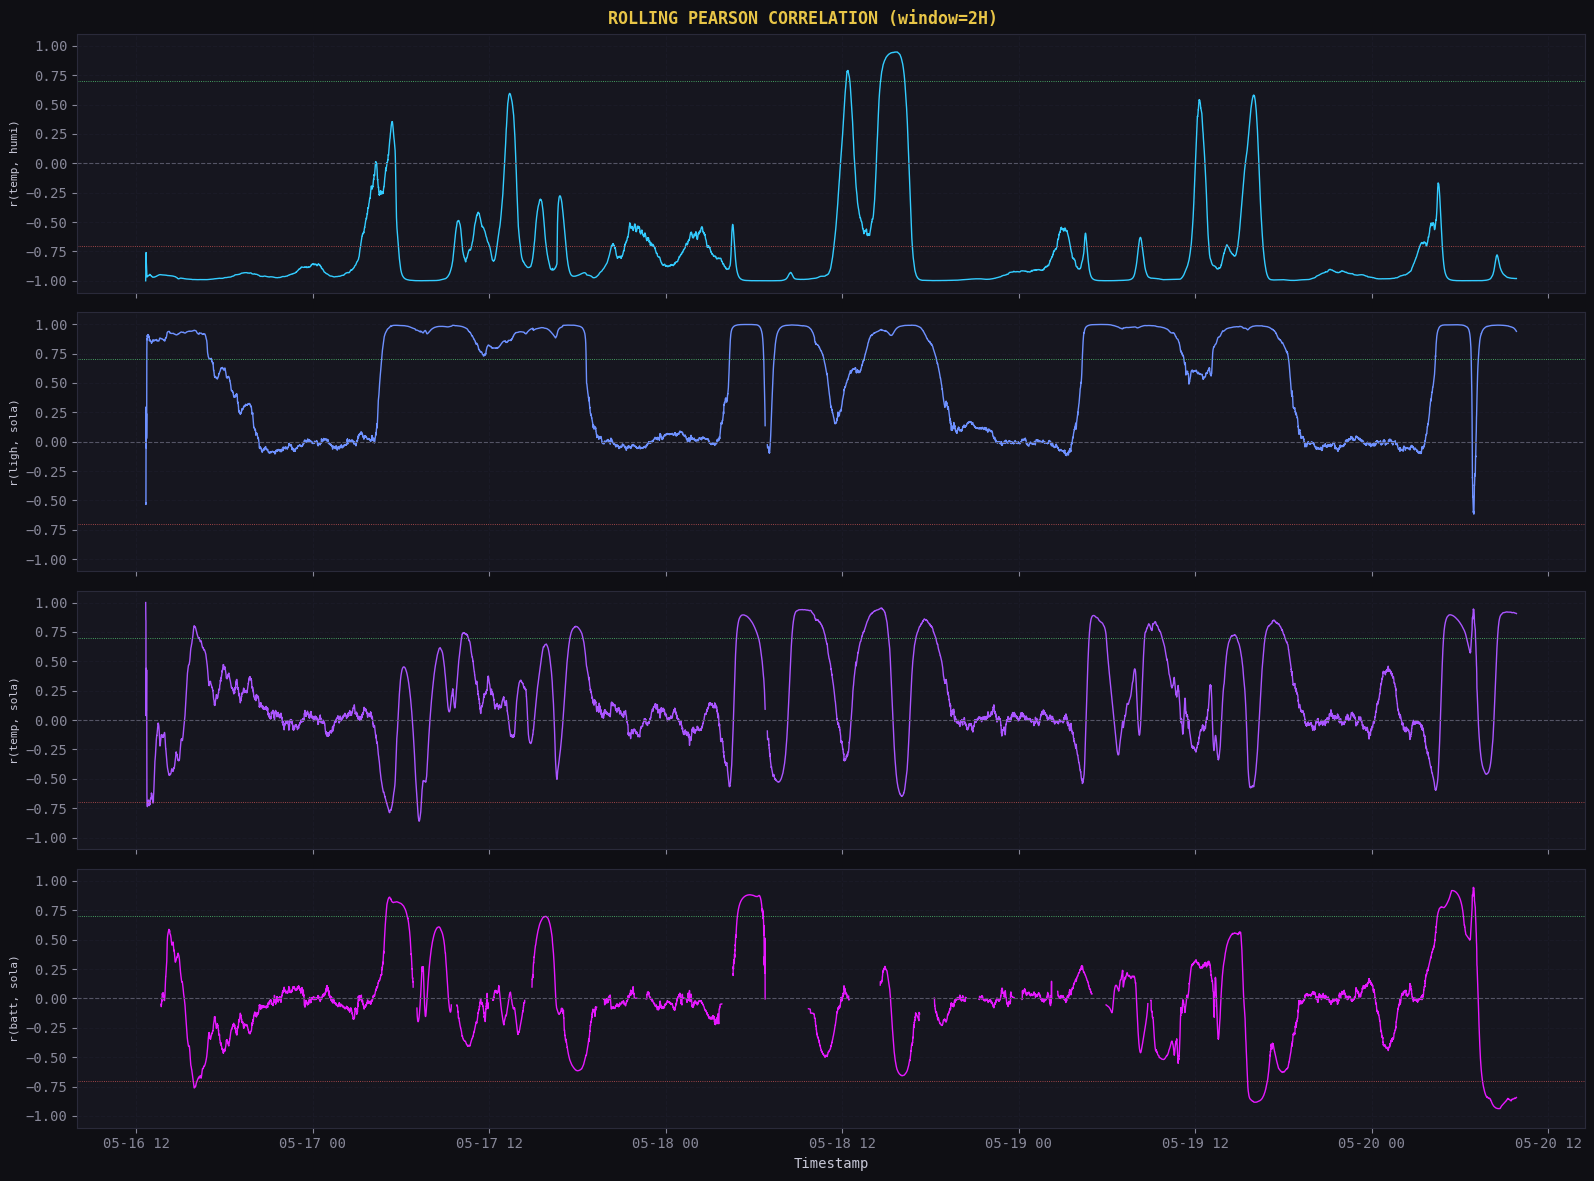

[PLOT] 04_rolling_correlation.png


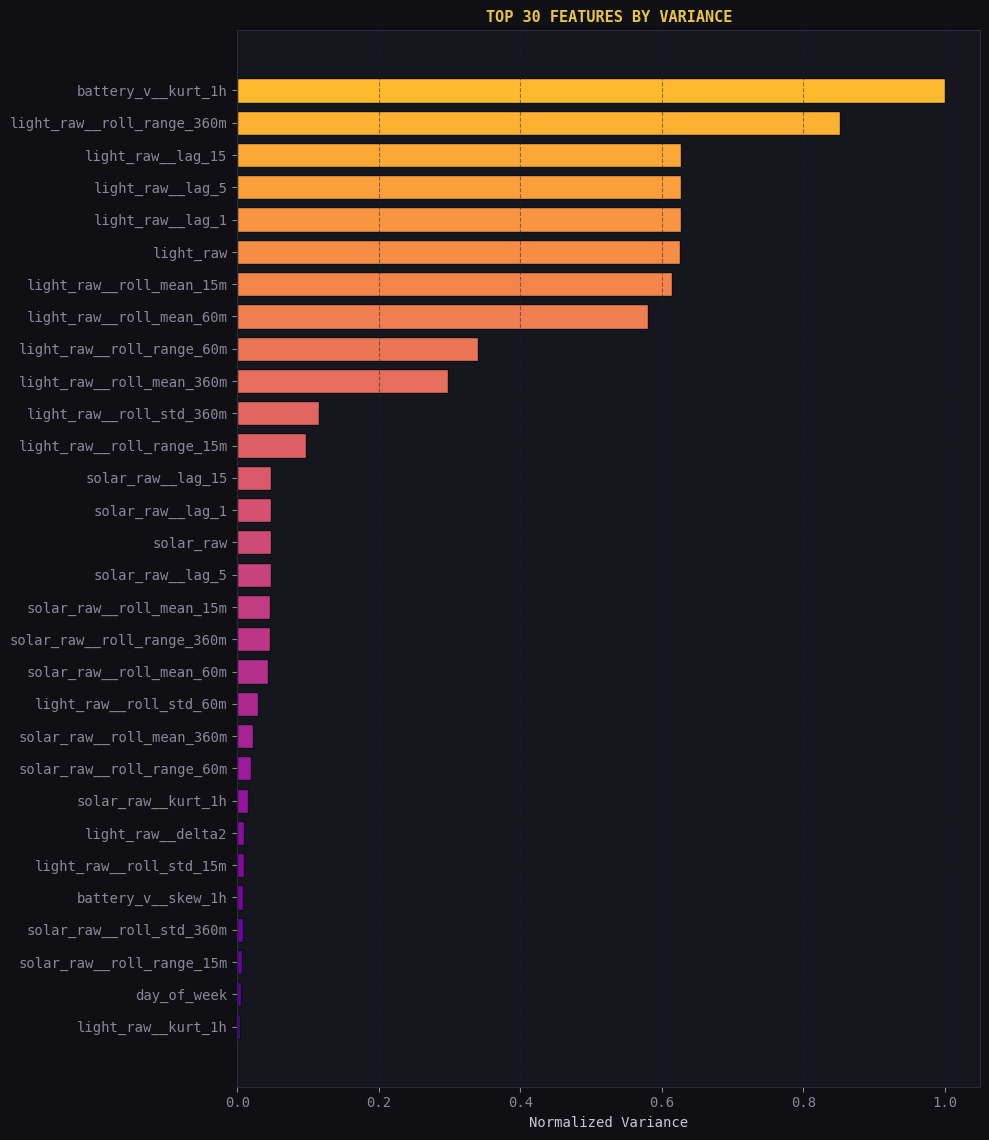

[PLOT] 05_feature_variance.png


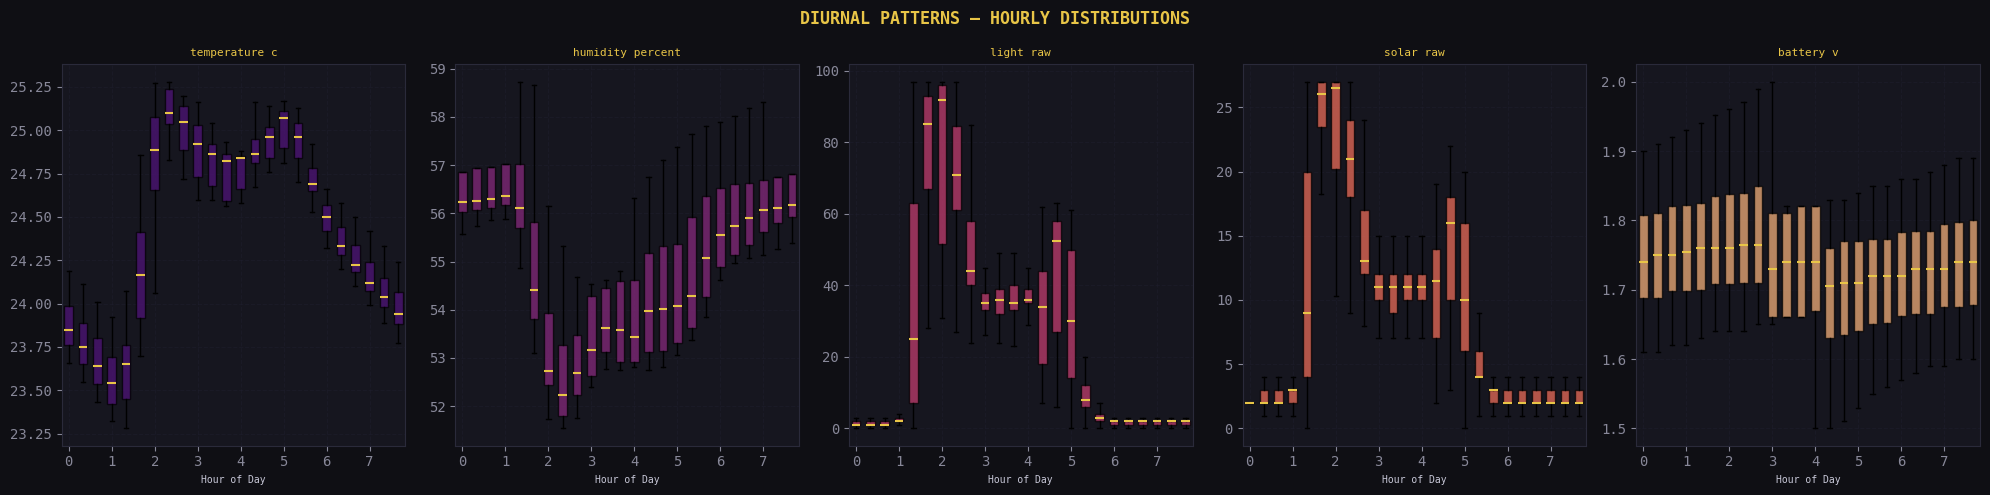

[PLOT] 06_diurnal_boxplots.png


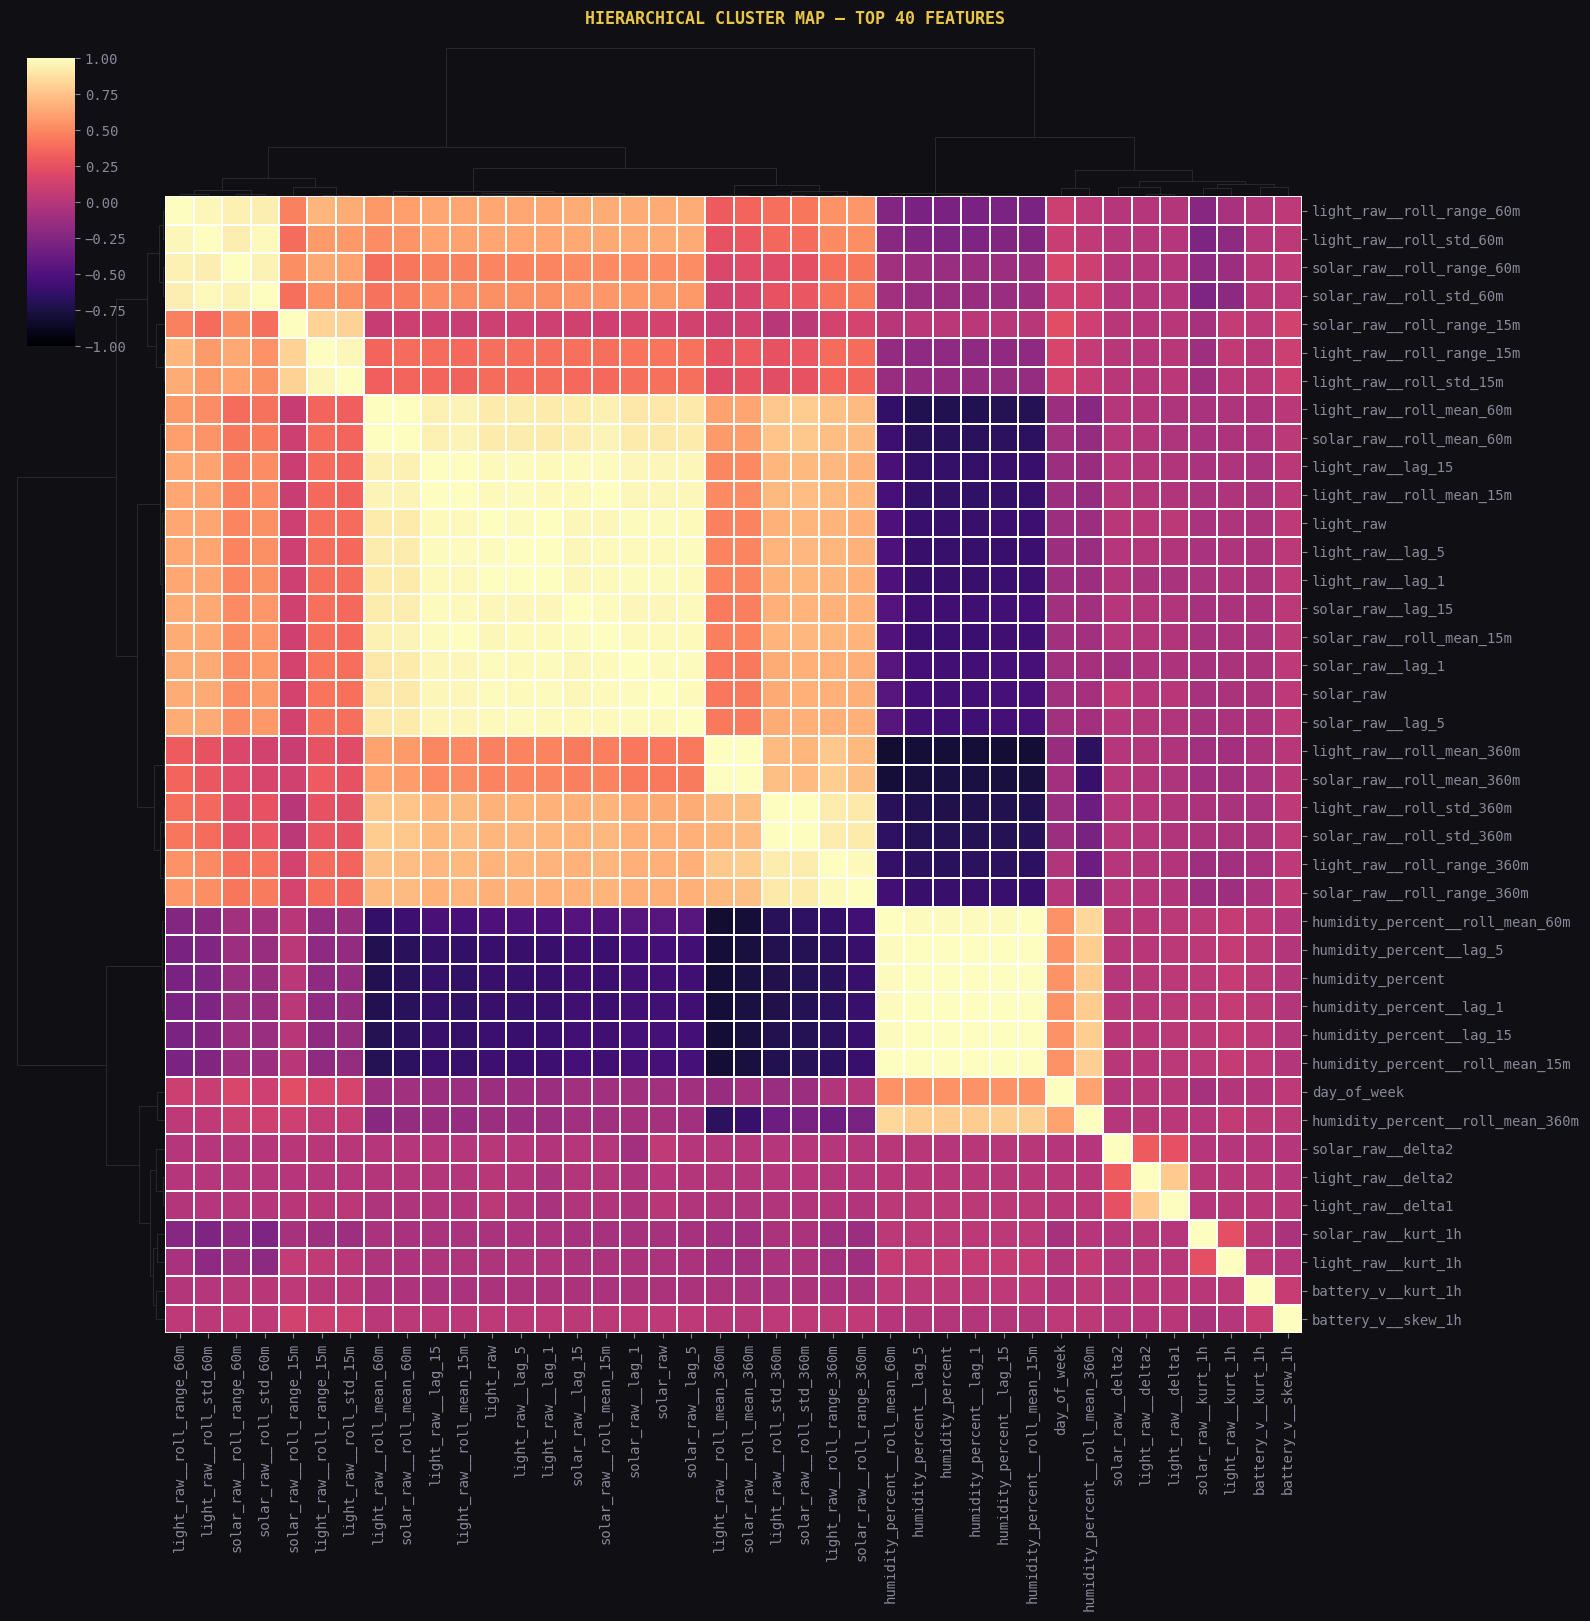

[PLOT] 07_clustermap.png

[DONE] All 7 plots saved.


(                                  temperature_c  humidity_percent  light_raw  \
 timestamp                                                                      
 2026-05-16 12:43:14.245000+00:00          25.24             56.08       17.0   
 2026-05-16 12:43:34.254000+00:00          25.23             56.08       18.0   
 2026-05-16 12:43:54.233000+00:00          25.26             56.11       18.0   
 2026-05-16 12:44:14.244000+00:00          25.31             55.98       19.0   
 2026-05-16 12:44:34.256000+00:00          25.31             55.89       19.0   
 ...                                         ...               ...        ...   
 2026-05-20 09:48:11.643000+00:00          24.63             52.59       33.0   
 2026-05-20 09:48:31.639000+00:00          24.63             52.62       33.0   
 2026-05-20 09:48:51.635000+00:00          24.63             52.59       32.0   
 2026-05-20 09:49:11.659000+00:00          24.63             52.56       33.0   
 2026-05-20 09:49:31.666000+

In [689]:
run_pipeline(df)

In [691]:
df["temp_lag_1"] = df["temperature_c"].shift(1)
df["temp_lag_3"] = df["temperature_c"].shift(3)

df["humidity_lag_1"] = df["humidity_percent"].shift(1)

df["light_lag_1"] = df["light_raw"].shift(1)

df["solar_lag_1"] = df["solar_raw"].shift(1)

df["temp_delta_1"] = df["temperature_c"].diff(1)

df["humidity_delta_1"] = df["humidity_percent"].diff(1)

df["light_delta_1"] = df["light_raw"].diff(1)

df["solar_delta_1"] = df["solar_raw"].diff(1)

seconds = (
    df["timestamp"].dt.hour * 3600 +
    df["timestamp"].dt.minute * 60 +
    df["timestamp"].dt.second
)

day = 24 * 3600

df["time_sin"] = np.sin(2 * np.pi * seconds / day)

df["time_cos"] = np.cos(2 * np.pi * seconds / day)

df["humidity_temp_interaction"] = (
    df["humidity_percent"] * df["temperature_c"]
)

